In [1]:
# Cài đặt tất cả các thư viện cần thiết cho Agentic RAG
%pip install langgraph langchain langchain-openai langgraph-checkpoint-sqlite feedparser pydantic python-dotenv requests langchain-community ipython ddgs

Note: you may need to restart the kernel to use updated packages.


In [14]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI

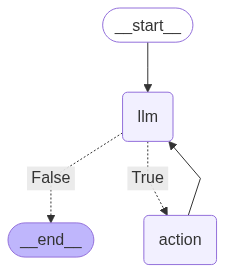

In [3]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import Image

# --- State của Agent ---
class AgentState(dict):
    pass

# --- Hàm xử lý ---
def call_openai(state: AgentState):
    pass

def exists_action(state: AgentState):
    pass

def take_action(state: AgentState):
    pass

# --- Build graph ---
graph = StateGraph(AgentState)
graph.add_node("llm", call_openai)
graph.add_node("action", take_action)
graph.add_conditional_edges("llm", exists_action, {True: "action", False: END})
graph.add_edge("action", "llm")
graph.set_entry_point("llm")

# --- Compile graph ---
app = graph.compile()



# Hiển thị Mermaid diagram trong notebook
Image(app.get_graph().draw_mermaid_png())


# Define Agent 

In [15]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [16]:
class Agent:
    def __init__(self, model, tools, checkpointer, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile(checkpointer=checkpointer)
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

# Thiết lập Prompt + model

In [17]:
import os 
from dotenv import load_dotenv
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""
model = ChatOpenAI(model="gpt-4o-mini")

## Define Tool 

In [18]:
from langchain.tools import BaseTool
from typing import Dict
import requests
from pydantic import Field
from dotenv import load_dotenv
import os

load_dotenv()
openweather_api_key = os.getenv("OPENWEATHER_API_KEY")

class OpenWeatherTool(BaseTool):
    name: str = "OpenWeather"
    description: str = "Get current weather information for a city using OpenWeather API."
    api_key: str = Field(..., description="OpenWeather API key")  # <-- phải import Field

    def _run(self, city: str) -> Dict:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={self.api_key}&units=metric"
        response = requests.get(url)
        data = response.json()
        if response.status_code != 200:
            return {"error": data.get("message", "Unknown error")}
        return {
            "city": data["name"],
            "country": data["sys"]["country"],
            "temperature": data["main"]["temp"],
            "humidity": data["main"]["humidity"],
            "weather": data["weather"][0]["description"],
            "wind_speed": data["wind"]["speed"]
        }

    async def _arun(self, city: str) -> Dict:
        return self._run(city)

# Khởi tạo tool
weather_tool = OpenWeatherTool(api_key=openweather_api_key)

# Test synchronous
print(weather_tool._run("Hanoi"))


{'city': 'Hanoi', 'country': 'VN', 'temperature': 26.48, 'humidity': 73, 'weather': 'overcast clouds', 'wind_speed': 0.6}


In [19]:
# !pip install feedparser

from langchain.tools import BaseTool
import feedparser
from typing import Optional, List, Dict

class ArxivSearchTool(BaseTool):
    name: str = "arXivSearch"
    description: str = "Search for scientific papers on arXiv by keyword."

    def _run(self, query: str) -> List[Dict]:
        """
        Synchronous run method
        """
        url = f"http://export.arxiv.org/api/query?search_query=all:{query.replace(' ', '+')}&start=0&max_results=5"
        feed = feedparser.parse(url)
        results = []
        for entry in feed.entries:
            results.append({
                "title": entry.title,
                "authors": [a.name for a in entry.authors],
                "published": entry.published,
                "link": entry.link
            })
        return results

    async def _arun(self, query: str) -> List[Dict]:
        """
        Asynchronous run method
        """
        return self._run(query)
arxiv_search_tool = ArxivSearchTool()
result = arxiv_search_tool._run("machine learning")
print(result)

[{'title': 'Lecture Notes: Optimization for Machine Learning', 'authors': ['Elad Hazan'], 'published': '2019-09-08T21:49:42Z', 'link': 'http://arxiv.org/abs/1909.03550v1'}, {'title': 'An Optimal Control View of Adversarial Machine Learning', 'authors': ['Xiaojin Zhu'], 'published': '2018-11-11T14:28:34Z', 'link': 'http://arxiv.org/abs/1811.04422v1'}, {'title': 'Minimax deviation strategies for machine learning and recognition with\n  short learning samples', 'authors': ['Michail Schlesinger', 'Evgeniy Vodolazskiy'], 'published': '2017-07-16T09:15:08Z', 'link': 'http://arxiv.org/abs/1707.04849v1'}, {'title': 'Machine Learning for Clinical Predictive Analytics', 'authors': ['Wei-Hung Weng'], 'published': '2019-09-19T22:02:00Z', 'link': 'http://arxiv.org/abs/1909.09246v1'}, {'title': 'Towards Modular Machine Learning Solution Development: Benefits and\n  Trade-offs', 'authors': ['Samiyuru Menik', 'Lakshmish Ramaswamy'], 'published': '2023-01-23T22:54:34Z', 'link': 'http://arxiv.org/abs/23

In [ ]:
# !pip install ddgs
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults
wrapper = DuckDuckGoSearchAPIWrapper(region="us-en", time="d", max_results=2)

search_duck_duck_tool = DuckDuckGoSearchResults(api_wrapper=wrapper, source="news")



("snippet: 5 hours ago — Donald Trump 's second and current tenure as the president of the United States began upon his inauguration as the 47th president on January 20, 2025., title: Second presidency of Donald Trump, link: https://en.wikipedia.org/wiki/Second_presidency_of_Donald_Trump, snippet: 6 hours ago — Latest news on President Donald Trump , including updates on his executive orders, administrative decisions from his team, news on his court cases and more., title: Donald Trump News: Latest on the U.S. President, link: https://www.nbcnews.com/politics/donald-trump, snippet: 5 hours ago — In analyst Nate Silver's aggregate of US national polls, Trump's net approval is currently -7.4 , with 51.6% disapproving and 44.2% approving. Trump's net ..., title: Polling shows Donald Trump's ratings are poor – but they ..., link: https://theconversation.com/polling-shows-donald-trumps-ratings-are-poor-but-they-could-be-worse-263785, snippet: 14 hours ago — U.S. President Donald Trump claim

In [11]:
from langchain.tools import BaseTool
from typing import Type
from pydantic import BaseModel, Field

# --- Schema input ---
class TourPriceInput(BaseModel):
    destination: str = Field(..., description="Tour destination: Ha Long, Sapa, Sai Gon")

# --- Mock Tool ---
class TourPriceTool(BaseTool):
    name: str = "tour_price_lookup"
    description: str = (
        "Look up mock information about tour ticket price and number of days "
        "for popular destinations (Ha Long, Sapa, Sai Gon). "
        "Input must be the destination name."
    )
    args_schema: Type[BaseModel] = TourPriceInput

    def _run(self, destination: str) -> dict:
        """Synchronous run"""
        data = {
            "Ha Long": {"price": "3,000,000 VND", "days": 3},
            "Sapa": {"price": "4,500,000 VND", "days": 4},
            "Sai Gon": {"price": "2,500,000 VND", "days": 2},
        }
        if destination not in data:
            return {"error": f"No mock data available for {destination}"}
        return {"destination": destination, **data[destination]}

    async def _arun(self, destination: str) -> dict:
        """Asynchronous run"""
        return self._run(destination)
tool_tour = TourPriceTool()

print(tool_tour.run({"destination": "Ha Long"}))
# Output: {'destination': 'Ha Long', 'price': '3,000,000 VND', 'days': 3}

print(tool_tour.run({"destination": "Da Nang"}))
# Output: {'error': 'No mock data available for Da Nang'}


{'destination': 'Ha Long', 'price': '3,000,000 VND', 'days': 3}
{'error': 'No mock data available for Da Nang'}


## Triển khai Agent

In [21]:
from pprint import pprint 
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import HumanMessage, AIMessage

# Chatbot đơn giản
thread = {"configurable": {"thread_id": "1"}}

with SqliteSaver.from_conn_string(":memory:") as memory:
    abot = Agent(
        model=model,
        tools=[weather_tool, arxiv_search_tool, search_duck_duck_tool],
        checkpointer=memory,
        system=prompt
    )
    
    print("Chatbot đã sẵn sàng! (Gõ 'quit' để thoát)")
    
    while True:
        user_input = input("\nBạn: ")
        
        if user_input.lower() == 'quit':
            print("Tạm biệt!")
            break
            
        messages = [HumanMessage(content=user_input)]
        print("You: ", user_input, end="\n")
        print("Bot: ", end="")
        for event in abot.graph.stream({"messages": messages}, thread):
            for v in event.values():
                if isinstance(v, dict) and "messages" in v:
                    for msg in v["messages"]:
                        if isinstance(msg, AIMessage):
                            print(msg.content)   # chỉ in content

        print()  # Xuống dòng

Chatbot đã sẵn sàng! (Gõ 'quit' để thoát)
You:  Ngày mai ở Hà Nội có mưa không
Bot: 
Calling: {'name': 'OpenWeather', 'args': {'city': 'Hà Nội'}, 'id': 'call_VzlmQSVNrn1f6rM77xlnZzHl', 'type': 'tool_call'}
Back to the model!

Calling: {'name': 'duckduckgo_results_json', 'args': {'query': 'Thời tiết Hà Nội ngày mai'}, 'id': 'call_3XIczuYJKlB0MxVFvfbWqwJI', 'type': 'tool_call'}
Back to the model!
Theo thông tin thời tiết hiện tại, Hà Nội có thời tiết nhiều mây và nhiệt độ khoảng 26,57°C. Tuy nhiên, hiện tại không có thông tin cụ thể về dự báo mưa cho ngày mai. 

Chúng ta có thể tìm hiểu thêm dự báo thời tiết cho ngày mai từ các nguồn thông tin như Dự báo thời tiết Việt Nam hoặc các trang web thời tiết địa phương. Nếu bạn có thêm thông tin cụ thể về thời gian hoặc nguồn tin nào cần tìm, hãy cho tôi biết!

You:  cho tôi 5 bài báo về RAG
Bot: 
Calling: {'name': 'arXivSearch', 'args': {'query': 'RAG'}, 'id': 'call_5zYLcfTgwoPUY681xlYmPwnY', 'type': 'tool_call'}
Back to the model!
Dưới đây là

KeyboardInterrupt: Interrupted by user